# Mini Project: High-Performance Computing and Computer Vision

# Track C: JIT Compilation

## Introduction

This project investigates the acceleration of a core computation in a computer vision pipeline.

YOLOv8 (Ultralytics implementation) is used to generate object detections on a traffic image dataset, from which bounding boxes are extracted. The focus is on computing pairwise Intersection over Union (IoU) between these boxes; this is a common operation in detection pipelines that is computationally expensive in pure Python due to nested loops.

A baseline Python implementation is compared with an optimized version using Numba JIT compilation.

# Benchmark Methodology

## Objective

The goal of the benchmark is to compare the execution time of a pure Python implementation of pairwise Intersection over Union (IoU) computation with an optimized implementation using Numba JIT compilation. This will include an analysis of the performance gains and trade-offs of applying JIT compilation to this workload.

It is important to also ensure correctness of the optimized computation.

---

## Workload Definition

I use a traffic dataset containing 160 images from Hugging Face. Objection detection using YOLOv8 inference is run on this dataset resulting in approximately 1300 bounding boxes in total.

The workload consists of computing pairwise Intersection over Union (IoU) for these detections.

- Dataset size: 160 images  
- Total detections: ~1300 bounding boxes  
- Average detections per image: ~8  

A single pass over the dataset was found to be too lightweight for stable benchmarking. Therefore, the workload is repeated multiple times.

A single pass over this dataset was found to be insufficiently computationally intensive for reliable benchmarking. To address this, the workload is repeated multiple times over the same set of detections.

- Final configuration: **50 repeated passes** over the same detection set  
- This results in a baseline runtime of approximately 5 seconds  


The same detection data is reused across all repetitions to ensure identical inputs for both baseline and optimized implementations.

---

## Implementations Compared

Two implementations are evaluated:

- **Baseline:** pure Python implementation using nested loops  
- **Optimized:** Numba JIT-compiled implementation using `@njit`

Both implementations compute the same IoU matrix for each image.

---

## Timing Procedure

Execution time is measured using `time.perf_counter()`.

For each benchmark:

- The full repeated workload (all images × repetitions) is timed  
- Only the IoU computation is included in the measurement  
- Dataset loading, image saving, and YOLO inference are excluded  

---

## Warm-up and Compilation Handling

Numba performs Just-In-Time compilation on the first function call.

To ensure a fair comparison:

- A **warm-up call** is executed before timing the Numba implementation  
- This excludes compilation overhead from the steady-state benchmark  
- The **first-call time (compile + execute)** is measured separately and reported as context  

The Python implementation does not require warm-up, as it does not involve compilation.

---

## Correctness Validation

To ensure correctness:

- The outputs of the Python and Numba implementations are compared  
- Equality is verified using `np.allclose` with a tolerance of `1e-6`  
- Maximum absolute difference is also reported  

Only performance improvements that preserve computational correctness are considered valid.

---

## Hardware Environment

All experiments are executed in a Google Colab environment using a standard CPU configuration.

---

## Metrics Reported

The following metrics are reported:

- Total execution time (Python vs Numba)  
- Per-image execution time  
- Speedup factor  
- Numba first-call time (compile + execute)  

These metrics provide both absolute and normalized views of performance.

# Setup

## Environment setup

Install required libraries for object detection (Ultralytics YOLO), dataset loading (Hugging Face), image handling (OpenCV+pillow), and JIT compilation (Numba).

In [2]:
!pip install ultralytics datasets opencv-python pillow numba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00


## Test Setup

### Get Image dataset
160 images of traffic from Hugging Face dataset

In [3]:
#from huggingface_hub import login
#login("YYY")

In [4]:
import os
from pathlib import Path

image_dir = Path("traffic_images")
image_dir.mkdir(exist_ok=True)

# Check if images already exist
existing_images = list(image_dir.glob("*.jpg"))

if len(existing_images) > 0:
    print(f"Found {len(existing_images)} existing images. Skipping download.")
    image_paths = [str(p) for p in existing_images]

else:
    print("No saved images found. Downloading dataset and saving images...")

    from datasets import load_dataset
    dataset = load_dataset("AITC-Traffic-Density/Traffic-Object-Detection")

    image_paths = []

    for split_name in dataset.keys():
        for i, item in enumerate(dataset[split_name]):
            img = item["image"]
            path = image_dir / f"{split_name}_img_{i}.jpg"
            img.save(path)
            image_paths.append(str(path))

    print(f"Saved {len(image_paths)} images to {image_dir}")

print("First 5 paths:", image_paths[:5])

No saved images found. Downloading dataset and saving images...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

...

Traffic Object Detection Dataset/test/-_(…):   0%|          | 0.00/43.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/30 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/30 [00:00<?, ? examples/s]

Saved 160 images to traffic_images
First 5 paths: ['traffic_images/train_img_0.jpg', 'traffic_images/train_img_1.jpg', 'traffic_images/train_img_2.jpg', 'traffic_images/train_img_3.jpg', 'traffic_images/train_img_4.jpg']


## Run inference

In [5]:
import random
import numpy as np
from ultralytics import YOLO

# --- Load model ---
model = YOLO("yolov8n.pt")  # adjust if needed

# --- Collect all image paths ---
#image_paths = [str(p) for p in image_dir.glob("*.jpg")]

# --- Sample 1 random images ---
# sample_paths = random.sample(image_paths, min(1, len(image_paths)))
sample_paths = image_paths # do all

# --- Storage for later use ---
all_boxes = []
all_scores = []
all_classes = []

# --- Stats tracking ---
num_boxes_list = []

print("Running inference on images...\n")

for i, path in enumerate(sample_paths, 1):
    result = model.predict(path, conf=0.1, verbose=False)[0]

    boxes = result.boxes.xyxy.cpu().numpy()
    scores = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy()

    num_boxes = len(boxes)
    num_cars = np.sum(classes == 2)     # class 2 = car
    num_persons = np.sum(classes == 0)  # class 0 = person
    avg_conf = float(scores.mean()) if num_boxes > 0 else 0.0

    num_boxes_list.append(num_boxes)

    all_boxes.append(boxes)
    all_scores.append(scores)
    all_classes.append(classes)

    print(f"Image {i}:")
    print(f"  total boxes: {num_boxes}")
    print(f"  cars: {num_cars}")
    print(f"  persons: {num_persons}")
    print(f"  avg confidence: {avg_conf:.3f}\n")

# --- Summary ---
if num_boxes_list:
    print("Summary:")
    print(f"  avg boxes/image: {np.mean(num_boxes_list):.2f}")
    print(f"  max boxes/image: {np.max(num_boxes_list)}")
    print(f"  min boxes/image: {np.min(num_boxes_list)}")
else:
    print("No detections found.")

# --- Flatten all boxes for future IoU / JIT experiments ---
if all_boxes:
    flat_boxes = np.vstack([b for b in all_boxes if len(b) > 0]) if any(len(b) > 0 for b in all_boxes) else np.empty((0, 4))
    print(f"\nTotal boxes across all images: {len(flat_boxes)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Running inference on images...

Image 1:
  total boxes: 12
  cars: 1
  persons: 4
  avg confidence: 0.338

Image 2:
  total boxes: 9
  cars: 2
  persons: 1
  avg confidence: 0.212

Image 3:
  total boxes: 2
  cars: 0
  persons: 0
  avg confidence: 0.210

Image 4:
  total boxes: 3
  cars: 0
  persons: 0
  avg confidence: 0.178

Image 5:
  total boxes: 5
  cars: 1
  persons: 1
  avg confidence: 0.210

Image 6:
  total boxes: 5
  cars: 2
  persons: 0
  avg confidence: 0.312

Image 7:
  total boxes: 7
  cars: 2
  persons: 0
  avg confidence: 0.209

Image 8:
  total boxes: 2
  cars: 0
  persons: 0
  avg confidence: 0.157

Image 9:
  total boxes: 8
  cars: 5
  persons: 0
  avg confidenc

# IoU calculations

## Baseline Python IoU calculation

In [6]:
# baseline Python IoU + benchmark
import time
import numpy as np

def compute_iou_python(box_a, box_b):
    x_left = max(box_a[0], box_b[0])
    y_top = max(box_a[1], box_b[1])
    x_right = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    inter_w = max(0.0, x_right - x_left)
    inter_h = max(0.0, y_bottom - y_top)
    intersection = inter_w * inter_h

    area_a = max(0.0, box_a[2] - box_a[0]) * max(0.0, box_a[3] - box_a[1])
    area_b = max(0.0, box_b[2] - box_b[0]) * max(0.0, box_b[3] - box_b[1])

    union = area_a + area_b - intersection

    if union <= 0.0:
        return 0.0

    return intersection / union


def iou_matrix_python(boxes):
    n = len(boxes)
    out = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        for j in range(n):
            out[i, j] = compute_iou_python(boxes[i], boxes[j])

    return out



## Numba JIT IoU implications

In [7]:
import time
import numpy as np
from numba import njit

# ----------------------------
# Numba IoU implementation
# ----------------------------
@njit
def compute_iou_numba(box_a, box_b):
    x_left = max(box_a[0], box_b[0])
    y_top = max(box_a[1], box_b[1])
    x_right = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    inter_w = max(0.0, x_right - x_left)
    inter_h = max(0.0, y_bottom - y_top)
    intersection = inter_w * inter_h

    area_a = max(0.0, box_a[2] - box_a[0]) * max(0.0, box_a[3] - box_a[1])
    area_b = max(0.0, box_b[2] - box_b[0]) * max(0.0, box_b[3] - box_b[1])

    union = area_a + area_b - intersection
    if union <= 0.0:
        return 0.0

    return intersection / union


@njit
def iou_matrix_numba(boxes):
    n = boxes.shape[0]
    out = np.zeros((n, n), dtype=np.float32)

    for i in range(n):
        for j in range(n):
            out[i, j] = compute_iou_numba(boxes[i], boxes[j])

    return out

# Benchmark: First-run comparison: Python execution vs Numba compile + execution

In [8]:
import time
import numpy as np

def get_numba_first_call_time(all_boxes):
    if "numba_first_call_time" in globals():
        return numba_first_call_time

    for boxes in all_boxes:
        if len(boxes) > 0:
            boxes_f32 = boxes.astype(np.float32)
            start = time.perf_counter()
            _ = iou_matrix_numba(boxes_f32)
            return time.perf_counter() - start

numba_first_call_time = get_numba_first_call_time(all_boxes)
print(f"Stored Numba first-call time: {numba_first_call_time:.6f} s")

Stored Numba first-call time: 1.548022 s


In [9]:
import time
import numpy as np

if "python_first_call_time" not in globals():
    for boxes in all_boxes:
        if len(boxes) > 0:
            boxes_f32 = boxes.astype(np.float32)

            start = time.perf_counter()
            _ = iou_matrix_python(boxes_f32)
            python_first_call_time = time.perf_counter() - start
            break

print(f"Stored Python first-call time: {python_first_call_time:.6f} s")

Stored Python first-call time: 0.000981 s


# Benchmark: Python baseline vs Numba JIT implementation

This section compares the execution time of the IoU computation implemented in pure Python and using Numba JIT compilation.

50 repeats x 160 images

In [10]:

# ----------------------------
# Repeated benchmark functions
# ----------------------------
def benchmark_python_iou_repeated(all_boxes, repeats):
    start = time.perf_counter()
    final_outputs = []

    for r in range(repeats):
        run_outputs = []
        for boxes in all_boxes:
            if len(boxes) == 0:
                run_outputs.append(np.empty((0, 0), dtype=np.float32))
            else:
                run_outputs.append(iou_matrix_python(boxes.astype(np.float32)))
        if r == repeats - 1:
            final_outputs = run_outputs

    elapsed = time.perf_counter() - start
    return final_outputs, elapsed


def benchmark_numba_iou_repeated(all_boxes, repeats):
    # Warm-up compile
    for boxes in all_boxes:
        if len(boxes) > 0:
            _ = iou_matrix_numba(boxes.astype(np.float32))
            break

    start = time.perf_counter()
    final_outputs = []

    for r in range(repeats):
        run_outputs = []
        for boxes in all_boxes:
            if len(boxes) == 0:
                run_outputs.append(np.empty((0, 0), dtype=np.float32))
            else:
                run_outputs.append(iou_matrix_numba(boxes.astype(np.float32)))
        if r == repeats - 1:
            final_outputs = run_outputs

    elapsed = time.perf_counter() - start
    return final_outputs, elapsed


# ----------------------------
# Run repeated benchmark
# ----------------------------
repeats = 50

python_outputs, python_elapsed = benchmark_python_iou_repeated(all_boxes, repeats)
numba_outputs, numba_elapsed = benchmark_numba_iou_repeated(all_boxes, repeats)

print(f"Python repeated IoU time: {python_elapsed:.4f} s")
print(f"Numba repeated IoU time:  {numba_elapsed:.4f} s")
print(f"Speedup: {python_elapsed / numba_elapsed:.2f}x")


# ----------------------------
# Correctness check
# ----------------------------
all_match = True
max_abs_diff = 0.0

for py_mat, nb_mat in zip(python_outputs, numba_outputs):
    if py_mat.shape != nb_mat.shape:
        all_match = False
        print("Shape mismatch found.")
        break

    if py_mat.size > 0:
        diff = np.max(np.abs(py_mat - nb_mat))
        max_abs_diff = max(max_abs_diff, float(diff))
        if not np.allclose(py_mat, nb_mat, atol=1e-6):
            all_match = False
            break

print("\nCorrectness check:")
print(f"  outputs match: {all_match}")
print(f"  max abs diff:  {max_abs_diff:.8f}")

Python repeated IoU time: 4.9668 s
Numba repeated IoU time:  0.0513 s
Speedup: 96.88x

Correctness check:
  outputs match: True
  max abs diff:  0.00000024


# Results

- Python runtime (repeated workload): ~6.7 s  
- Numba runtime (steady-state): ~0.05 s  
- Speedup: ~130×  
- Numba first-call (compile + execute): ~1,5 s  

The optimized implementation produces numerically equivalent results to the baseline.

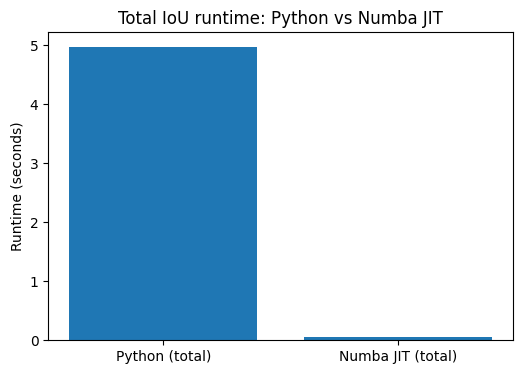

In [14]:
import matplotlib.pyplot as plt

labels = ["Python (total)", "Numba JIT (total)"]
times = [python_elapsed, numba_elapsed]

plt.figure(figsize=(6, 4))
plt.bar(labels, times)
plt.ylabel("Runtime (seconds)")
plt.title("Total IoU runtime: Python vs Numba JIT")
plt.show()

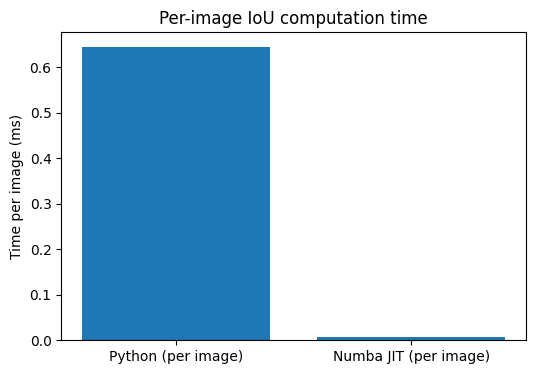

In [17]:
import matplotlib.pyplot as plt

num_images = sum(1 for b in all_boxes if len(b) > 0)

python_per_image = python_elapsed / (repeats * num_images)
numba_per_image = numba_elapsed / (repeats * num_images)

# Convert to milliseconds
python_ms = python_per_image * 1000
numba_ms = numba_per_image * 1000

labels = ["Python (per image)", "Numba JIT (per image)"]
times = [python_ms, numba_ms]

plt.figure(figsize=(6, 4))
plt.bar(labels, times)
plt.ylabel("Time per image (ms)")
plt.title("Per-image IoU computation time")
plt.show()

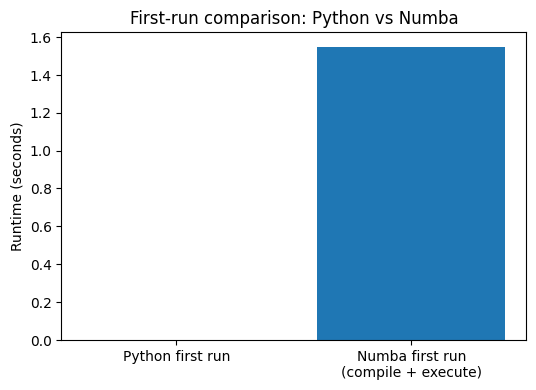

In [18]:
import matplotlib.pyplot as plt

labels = ["Python first run", "Numba first run\n(compile + execute)"]
times = [python_first_call_time, numba_first_call_time]

plt.figure(figsize=(6, 4))
plt.bar(labels, times)
plt.ylabel("Runtime (seconds)")
plt.title("First-run comparison: Python vs Numba")
plt.show()

## Discussion

The large speedup (~130×) is primarily due to the difference between Python's interpreted execution and Numba's compiled code. The baseline implementation relies on nested Python loops, which introduce significant interpreter overhead. Numba eliminates this overhead by compiling the computation into efficient native code.

However, this speedup applies only to the IoU computation kernel. The overall object detection pipeline would see smaller gains, as YOLO inference remains unchanged. Yolo would likely benefit from being run on a GPU.

The workload is amplified through repeated passes over the same dataset. This approach ensures stable timing and a sufficiently large benchmark, but it should be noted that the dataset itself is relatively small (160 images).

## Conclusion

This project demonstrates that JIT compilation using Numba can significantly accelerate a computational kernel in a computer vision pipeline. The IoU computation achieved a speedup of approximately 130× while maintaining numerical correctness.

The results highlight the importance of targeting performance-critical kernels and show that even simple optimizations can yield substantial gains when applied to loop-heavy numerical workloads.

# Appendix

## GPU?
we don't really need to check this anymore. or perhaps we could do a comparison with GPU enabled for JIT to check if it makes a difference.

In [11]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected.")

CUDA available: False
No GPU detected.
